# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `ames_housing(1).csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_candidates = [
    Path(r"C:\Machine_Learning_worksheet\Data\ames_housing.csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
생활 면적이 1단위 증가할때 마다 모델이 예측하는 매매 가격이 평균적으로 약 107.13만큼 증가한다는 의미

- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
생활 면적이 0이라도 약 18,569 달러를 내야한것을 의미한다.

- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?
-> 실제값과 예측값의 차이인 잔차를 제곱해 모두 더한 SSE값이 가장 작아지는 기울기와 절편을 선택한다.



[1] 분석용 데이터
    원본 1460행 -> 결측 제거 후 1460행
    GrLivArea 결측 0개, SalePrice 결측 0개

[2] 평균
    x_bar (평균 생활면적) = 1,515.4637 제곱피트
    y_bar (평균 매매가격) = 180,921.1959 달러

[3] 회귀계수 직접 계산
    Sxy = sum((xi-x_bar)(yi-y_bar)) = 43,159,943,578.3822
    Sxx = sum((xi-x_bar)^2)         = 402,873,135.0760
    beta1 = Sxy / Sxx = 107.130359
    beta0 = y_bar - beta1*x_bar = 180,921.1959 - 107.130359 x 1,515.4637 = 18569.025856

    [검증] scipy.stats.linregress 와 비교
    기울기 직접=107.130359 | scipy=107.130359 | 일치=True
    절편   직접=18569.025856 | scipy=18569.025856 | 일치=True

[4] 회귀식
    y_hat = 107.1304 * x + 18,569.0259
    (매매가격 = 107.1304 x 생활면적 + 18,569.0259)

    생활면적 1,500 제곱피트일 때 예측 매매가격
    y_hat = 18569.0259 + 107.1304 x 1,500 = $179,264.56

    [참고] 적합도
    r^2  = 0.5021  (= 상관계수 r = 0.7086 의 제곱)
    RMSE = $56,034.30  (예측의 평균적인 오차 크기)
    SSE  = 4,584,171,086,113.13  (잔차 제곱합, 최소제곱법이 최소화한 값)

    [확인] 기울기를 바꿔보면 SSE 가 반드시 커집니다
      beta1 = 105.1304 -> SSE = 4,585,782,578,653
      beta1 = 106.130

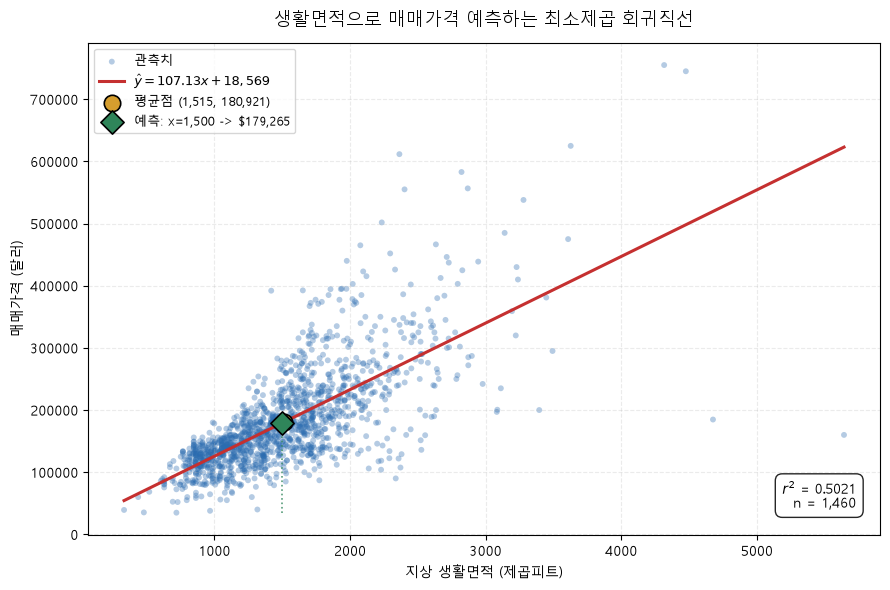

[5] 산점도 저장: regression_line.png

[해석 보조]
    x 의 실제 관측 범위: 334 ~ 5,642 제곱피트
    -> x = 0 은 이 범위 밖이므로 절편은 외삽(extrapolation) 값입니다.
    100 제곱피트 넓어질 때 예측 가격 차이: $10,713


In [4]:
# 여기에 코드를 작성하세요.
"""
GrLivArea(x) -> SalePrice(y) 최소제곱 회귀직선 직접 계산
공식만 이용해 기울기 beta1, 절편 beta0 를 구한다.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats

# ---------------------------------------------------------------
# 한글 폰트 설정 (없으면 영문 라벨 사용)
# ---------------------------------------------------------------
KOREAN_OK = False
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
           "NanumBarunGothic", "Noto Sans CJK KR"]:
    try:
        font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        plt.rcParams["axes.unicode_minus"] = False
        KOREAN_OK = True
        break
    except Exception:
        continue


def L(ko, en):
    return ko if KOREAN_OK else en


# ---------------------------------------------------------------
# 데이터 불러오기
# ---------------------------------------------------------------
data_candidates = [
    Path(r"C:\Machine_Learning_worksheet\Data\ames_housing.csv"),
    Path("ames_housing.csv"),
    Path("train.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("ames_housing CSV 경로를 확인하세요.")

df = pd.read_csv(data_path)
df.columns = df.columns.str.replace(" ", "", regex=False)

# ---------------------------------------------------------------
# 1. 두 변수의 결측치를 제거한 분석용 데이터
# ---------------------------------------------------------------
data = df[["GrLivArea", "SalePrice"]].dropna()

print("[1] 분석용 데이터")
print(f"    원본 {len(df)}행 -> 결측 제거 후 {len(data)}행")
print(f"    GrLivArea 결측 {df['GrLivArea'].isna().sum()}개, "
      f"SalePrice 결측 {df['SalePrice'].isna().sum()}개\n")

x = data["GrLivArea"].to_numpy(dtype=float)   # 독립변수
y = data["SalePrice"].to_numpy(dtype=float)   # 종속변수
n = len(x)

# ---------------------------------------------------------------
# 2. x 와 y 의 평균
# ---------------------------------------------------------------
x_bar = x.mean()
y_bar = y.mean()

print("[2] 평균")
print(f"    x_bar (평균 생활면적) = {x_bar:,.4f} 제곱피트")
print(f"    y_bar (평균 매매가격) = {y_bar:,.4f} 달러\n")

# ---------------------------------------------------------------
# 3. 공식으로 기울기 beta1, 절편 beta0 계산
#    beta1 = sum((xi - x_bar)(yi - y_bar)) / sum((xi - x_bar)^2)
#    beta0 = y_bar - beta1 * x_bar
# ---------------------------------------------------------------
dx = x - x_bar          # 편차
dy = y - y_bar

Sxy = np.sum(dx * dy)   # 분자: 편차곱의 합
Sxx = np.sum(dx ** 2)   # 분모: x 편차 제곱합

beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar

print("[3] 회귀계수 직접 계산")
print(f"    Sxy = sum((xi-x_bar)(yi-y_bar)) = {Sxy:,.4f}")
print(f"    Sxx = sum((xi-x_bar)^2)         = {Sxx:,.4f}")
print(f"    beta1 = Sxy / Sxx = {beta1:.6f}")
print(f"    beta0 = y_bar - beta1*x_bar = {y_bar:,.4f} - "
      f"{beta1:.6f} x {x_bar:,.4f} = {beta0:.6f}\n")

# 검증: scipy 와 비교
lr = stats.linregress(x, y)
print("    [검증] scipy.stats.linregress 와 비교")
print(f"    기울기 직접={beta1:.6f} | scipy={lr.slope:.6f} | "
      f"일치={np.isclose(beta1, lr.slope)}")
print(f"    절편   직접={beta0:.6f} | scipy={lr.intercept:.6f} | "
      f"일치={np.isclose(beta0, lr.intercept)}\n")

# ---------------------------------------------------------------
# 4. 회귀식 출력 + 생활면적 1500 일 때 예측
# ---------------------------------------------------------------
print("[4] 회귀식")
sign = "+" if beta0 >= 0 else "-"
print(f"    y_hat = {beta1:.4f} * x {sign} {abs(beta0):,.4f}")
print(f"    (매매가격 = {beta1:.4f} x 생활면적 {sign} {abs(beta0):,.4f})\n")

x_new = 1500
y_pred = beta0 + beta1 * x_new

print(f"    생활면적 {x_new:,} 제곱피트일 때 예측 매매가격")
print(f"    y_hat = {beta0:.4f} + {beta1:.4f} x {x_new:,} = ${y_pred:,.2f}\n")

# 적합도 참고
y_hat = beta0 + beta1 * x
resid = y - y_hat
sse = np.sum(resid ** 2)
sst = np.sum((y - y_bar) ** 2)
r_squared = 1 - sse / sst
rmse = np.sqrt(sse / n)

print("    [참고] 적합도")
print(f"    r^2  = {r_squared:.4f}  (= 상관계수 r = {np.sqrt(r_squared):.4f} 의 제곱)")
print(f"    RMSE = ${rmse:,.2f}  (예측의 평균적인 오차 크기)")
print(f"    SSE  = {sse:,.2f}  (잔차 제곱합, 최소제곱법이 최소화한 값)\n")

# 최소제곱임을 확인: 기울기를 조금 바꾸면 SSE 가 커진다
print("    [확인] 기울기를 바꿔보면 SSE 가 반드시 커집니다")
for delta in [-2, -1, 0, 1, 2]:
    b1 = beta1 + delta
    b0 = y_bar - b1 * x_bar
    sse_alt = np.sum((y - (b0 + b1 * x)) ** 2)
    mark = "  <- 최소" if delta == 0 else ""
    print(f"      beta1 = {b1:8.4f} -> SSE = {sse_alt:,.0f}{mark}")
print()

# ---------------------------------------------------------------
# 5. 산점도 위에 회귀직선 그리기
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, s=18, alpha=0.35, color="#2b6cb0", edgecolor="none",
           label=L("관측치", "observations"))

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, beta0 + beta1 * x_line, color="#c53030", linewidth=2.2,
        label=f"$\\hat{{y}} = {beta1:.2f}x {sign} {abs(beta0):,.0f}$")

# 평균점 (x_bar, y_bar) 은 회귀직선 위에 반드시 놓인다
ax.scatter([x_bar], [y_bar], s=140, color="#d69e2e", edgecolor="black",
           linewidth=1.2, zorder=5,
           label=L(f"평균점 ({x_bar:,.0f}, {y_bar:,.0f})",
                   f"mean point ({x_bar:,.0f}, {y_bar:,.0f})"))

# 예측 지점 표시
ax.scatter([x_new], [y_pred], s=140, marker="D", color="#2f855a",
           edgecolor="black", linewidth=1.2, zorder=5,
           label=L(f"예측: x={x_new:,} -> ${y_pred:,.0f}",
                   f"prediction: x={x_new:,} -> ${y_pred:,.0f}"))
ax.plot([x_new, x_new], [y.min(), y_pred], color="#2f855a",
        linestyle=":", linewidth=1.2, alpha=0.8)

ax.set_title(L("생활면적으로 매매가격 예측하는 최소제곱 회귀직선",
               "Least-squares regression: Living Area -> Sale Price"),
             fontsize=13, pad=12)
ax.set_xlabel(L("지상 생활면적 (제곱피트)", "Above Ground Living Area (sq ft)"))
ax.set_ylabel(L("매매가격 (달러)", "Sale Price (USD)"))
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.25, linestyle="--")

ax.text(0.97, 0.05, f"$r^2$ = {r_squared:.4f}\nn = {n:,}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85))

plt.tight_layout()
plt.savefig("regression_line.png", dpi=150)
plt.show()

print("[5] 산점도 저장: regression_line.png")

# ---------------------------------------------------------------
# 해석용 보조 정보
# ---------------------------------------------------------------
print("\n[해석 보조]")
print(f"    x 의 실제 관측 범위: {x.min():,.0f} ~ {x.max():,.0f} 제곱피트")
print(f"    -> x = 0 은 이 범위 밖이므로 절편은 외삽(extrapolation) 값입니다.")
print(f"    100 제곱피트 넓어질 때 예측 가격 차이: ${beta1 * 100:,.0f}")

---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
현재 데이터에서 매매 가격 전체 변동의 약 50.2% 를 생활면적과 의 선형 회귀 모델이 설명한다는 의미
- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
아니다. 양의 잔차와 음의 잔차가 상쇄될 수 있다. 잔차의 크기와 패터 파악이 추가적으로 필요하다
- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
높은 예측 가격 구간에서 잔차와 퍼짐이 커지는 경향과 회구선에서 매우 멀리 떨어진 관측치가 보인다.

- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?


In [ ]:
# 여기에 코드를 작성하세요.


---

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?
x = 독립 변수
y = 종속변수 
a= 기울기 (건축년도)
b = 절편  (예측 가격)

- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
r^2 은 실행값으로 건욱 연도가 매매가격 변동에만 설명한다. 나머지는 변수에 적용이 안된 변수이기에 설명력이 높다곤 못함

- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
주의 할점은 예측값이 커질수록 잔차(residual)의 흩어짐도 함께 커지는 깔때기 모양이 나타나 등분산 가정에 위반함. 또 잔차가 0선 주변에 무작위로 흩어지지 않고 곡선 패턴을 보이면 관계가 비선형(non-linear)이라는 뜻. 

- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.
건축연도 하나만으로 가격을 설명하는데 한계까 잇따. GriLivArea나 OverallQual을 추가한 다중회귀로 확장하거나, saleprice에 로그 변환을 적용해 등분산성을 개선할것을 고려할수 잇다.



> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


기울기(slope)  : 1375.3735
절편(intercept): -2530308.2457
회귀식: SalePrice = 1375.37 × YearBuilt + (-2530308.25)

SSE : 6,690,269,293,939.84
SST : 9,207,911,334,609.98
R²  : 0.2734  (매매가격 분산의 27.34% 설명)

[검산] scipy slope=1375.3735, intercept=-2530308.2457, r²=0.2734

건축연도 2000년 예측 매매가격: $220,438.69


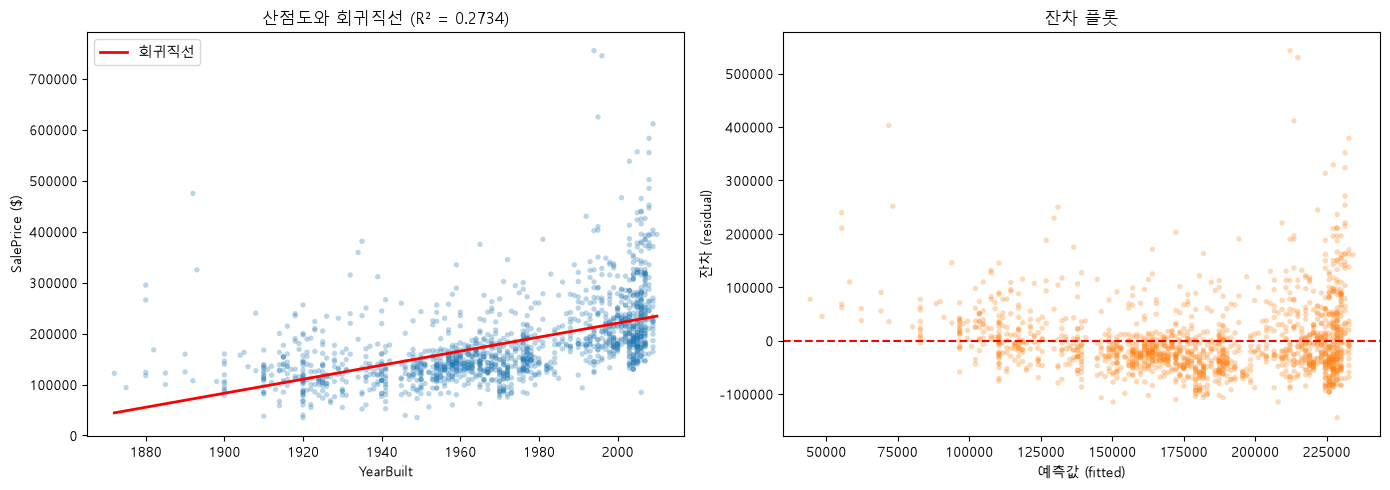


잔차 평균: 0.000000  (0에 가까우면 정상)
잔차 표준편차: 67716.45


In [3]:
# 여기에 코드를 작성하세요.
x = df["YearBuilt"]
y = df["SalePrice"]
n = len(df)

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # 윈도우 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

# 1. 최소제곱법으로 기울기와 절편 직접 계산
x_mean, y_mean = x.mean(), y.mean()
slope = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
intercept = y_mean - slope * x_mean

print(f"기울기(slope)  : {slope:.4f}")
print(f"절편(intercept): {intercept:.4f}")
print(f"회귀식: SalePrice = {slope:.2f} × YearBuilt + ({intercept:.2f})")

# 2. 예측값, 잔차, SSE, SST, R²
y_pred = slope * x + intercept
residuals = y - y_pred

sse = (residuals ** 2).sum()          # 잔차제곱합
sst = ((y - y_mean) ** 2).sum()       # 총제곱합
r_squared = 1 - sse / sst

print(f"\nSSE : {sse:,.2f}")
print(f"SST : {sst:,.2f}")
print(f"R²  : {r_squared:.4f}  (매매가격 분산의 {r_squared*100:.2f}% 설명)")

# 검산: scipy 결과와 비교
from scipy import stats as st
res = st.linregress(x, y)
print(f"\n[검산] scipy slope={res.slope:.4f}, intercept={res.intercept:.4f}, r²={res.rvalue**2:.4f}")

# 3. 건축연도 2000년 주택의 매매가격 예측
pred_2000 = slope * 2000 + intercept
print(f"\n건축연도 2000년 예측 매매가격: ${pred_2000:,.2f}")

# 4. 산점도 + 회귀직선, 잔차 플롯
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x, y, alpha=0.3, s=15, edgecolors="none")
xs = np.array([x.min(), x.max()])
axes[0].plot(xs, slope * xs + intercept, color="red", lw=2, label="회귀직선")
axes[0].set_xlabel("YearBuilt")
axes[0].set_ylabel("SalePrice ($)")
axes[0].set_title(f"산점도와 회귀직선 (R² = {r_squared:.4f})")
axes[0].legend()

axes[1].scatter(y_pred, residuals, alpha=0.3, s=15, edgecolors="none", color="tab:orange")
axes[1].axhline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("예측값 (fitted)")
axes[1].set_ylabel("잔차 (residual)")
axes[1].set_title("잔차 플롯")

plt.tight_layout()
plt.show()

print(f"\n잔차 평균: {residuals.mean():.6f}  (0에 가까우면 정상)")
print(f"잔차 표준편차: {residuals.std():.2f}")

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.
